# Notebook Objectives

In this notebooks, we'll go through the main behavioral analysis results.

Results include:
* ?
* ?

---
# Setup


In [1]:
##% title Imports
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import pandas as pd

import popy.config as cfg

PATH = cfg.PROJECT_PATH_LOCAL


In [2]:
##% Plotting Functions

# fontsize = 8
plt.rcParams.update({'font.size': 12})

def create_r_style_plot(ax, data, x_col, y_col, palette, title):
    """Create R-style plot with violin, box, and jittered points"""
    
    # Get unique categories
    # sort by x_col
    data = data.copy().sort_values(by=x_col)
    categories = data[x_col].unique()
    x_positions = np.arange(len(categories))
    
    # Create violin plots (distributions) - slightly offset to the right
    violin_parts = ax.violinplot([data.loc[data[x_col] == cat, y_col].values for cat in categories], 
                                positions=x_positions + 0.15, widths=0.3, showmeans=False, 
                                showmedians=False, showextrema=False)
    
    # Color the violin plots
    colors = [palette[str(cat)] for cat in categories]
    for pc, color in zip(violin_parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.3)
        pc.set_edgecolor('black')
        pc.set_linewidth(0.5)
    
    # Create boxplots - centered
    box_data = [data.loc[data[x_col] == cat, y_col].values for cat in categories]
    bp = ax.boxplot(box_data, positions=x_positions, widths=0.2, patch_artist=True,
                   boxprops=dict(alpha=0.7, linewidth=1.5),
                   showfliers=False,
                   medianprops=dict(color='black', linewidth=2),
                   whiskerprops=dict(linewidth=1.5),
                   capprops=dict(linewidth=1.5),
                   flierprops=dict(marker='o', markerfacecolor='black', markersize=3, alpha=0.5))
    
    # Color the boxes
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    # Add jittered points - slightly offset to the left
    for i, cat in enumerate(categories):
        y_data = data.loc[data[x_col] == cat, y_col].values
        x_jitter = np.random.normal(x_positions[i] - 0.15, 0.04, size=len(y_data))
        ax.scatter(x_jitter, y_data, alpha=0.6, s=20, 
                  color=colors[i], edgecolor='black', linewidth=0.5)
    
    # Perform t-test and add significance
    if len(categories) == 2:
        group1_data = data.loc[data[x_col] == categories[0], y_col]
        group2_data = data.loc[data[x_col] == categories[1], y_col]
        #_, p_value = stats.ttest_ind(group1_data, group2_data)
        _, p_value = stats.mannwhitneyu(group1_data, group2_data, alternative='two-sided')

        
        # Position for significance bar
        y_max = data[y_col].max()
        y_pos = y_max + 0.1 * abs(y_max)
        
        # Add significance annotation
        if p_value < 0.001:
            significance = '***'
        elif p_value < 0.01:
            significance = '**'
        elif p_value < 0.05:
            significance = '*'
        else:
            significance = 'n.s.'
        
        # Add the bar and text for p-value
        ax.plot([0, 1], [y_pos, y_pos], '-k', lw=1.5)
        ax.text(0.5, y_pos + 0.02 * abs(y_max), f'p = {p_value:.3f} {significance}, n={len(group1_data)}', 
                ha='center', va='bottom', fontsize=10)
    
    # Formatting
    ax.axhline(0, linestyle='--', alpha=0.7, color='black')
    ax.set_xticks(x_positions)
    ax.set_xticklabels(['Unrewarded', 'Rewarded'])
    ax.set_ylabel('Change in neural value \n$\Delta V = V_t - V_{t-1}$')
    ax.set_xlabel('')
    ax.set_title(title)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    return ax




---
# Get data

In [3]:
from popy.config import PROJECT_PATH_LOCAL as PATH

path = os.path.join(cfg.PROJECT_PATH_LOCAL, 'notebooks', 'population_decoding', 'results', 'behav_neural_value_across_target', 'behav.pkl')

results_df = pd.read_pickle(path)
# sort by monkey session trial_id target type
#results_df_all = results_df_all.sort_values(by=['monkey', 'session', 'trial_id', 'target', 'type'])
results_df

,trial_id,target,feedback,type,V_neural,V_neural_p1,dV_neural,V_behav,V_behav_p1,dV_behav,monkey,session,subregion
0,8,1.0,0,within,0.009310,0.006475,-0.002835,0.5767405984530025,0.3404883021116374,0.236252,ka,230520,MCC
1,8,1.0,0,alter,-0.010519,-0.008008,0.002512,0.5767405984530025,0.3404883021116374,0.236252,ka,230520,MCC
2,8,1.0,0,alter,-0.020904,-0.004788,0.016116,0.5767405984530025,0.3404883021116374,0.236252,ka,230520,MCC
3,9,1.0,1,within,0.006475,-0.008796,-0.015271,0.3404883021116374,0.6106464174030739,-0.270158,ka,230520,MCC
4,9,1.0,1,alter,-0.008008,0.009453,0.017460,0.3404883021116374,0.6106464174030739,-0.270158,ka,230520,MCC
...,...,...,...,...,...,...,...,...,...,...,...,...,...
174934,374,1.0,1,alter,0.054962,0.045289,-0.009672,0.654678927748392,0.7595868255905716,-0.104908,po,200722,dLPFC
174935,374,1.0,1,alter,0.036240,0.143726,0.107486,0.654678927748392,0.7595868255905716,-0.104908,po,200722,dLPFC
174936,375,1.0,1,within,0.136303,0.066825,-0.069478,0.7595868255905716,0.8326238996863039,-0.073037,po,200722,dLPFC
174937,375,1.0,1,alter,0.045289,0.067340,0.022050,0.7595868255905716,0.8326238996863039,-0.073037,po,200722,dLPFC


Text(0.5, 1.05, 'ka MCC 210322')

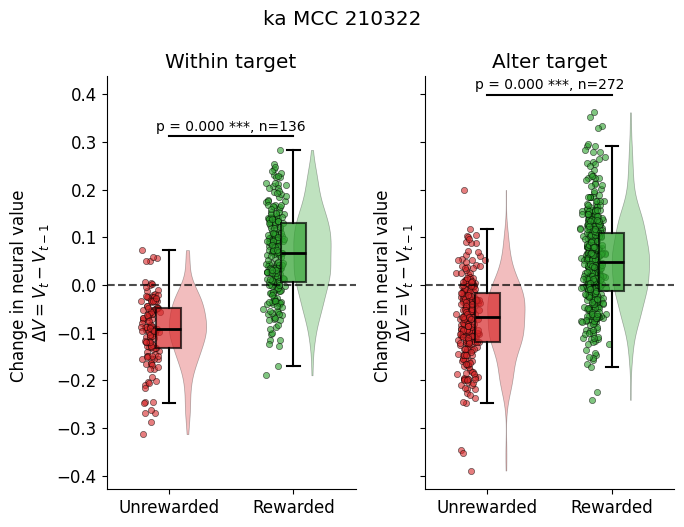

In [10]:
results_df_temp = results_df[(results_df['session'] == '210322') &
                             (results_df['subregion'] == 'MCC')]

# Create the figure
fig, axs = plt.subplots(1, 2, figsize=(7, 5), sharey=True)

# Create the plots
palette = {'0': 'tab:red', '1': 'tab:green'}

# Within target plot
create_r_style_plot(axs[0], 
                   results_df_temp.loc[results_df_temp['type'] == 'within'], 
                   'feedback', 'dV_neural', palette, 'Within target')

# Alter target plot
create_r_style_plot(axs[1], 
                   results_df_temp.loc[results_df_temp['type'] == 'alter'], 
                   'feedback', 'dV_neural', palette, 'Alter target')

plt.tight_layout()
plt.suptitle(f'{results_df_temp["monkey"].unique()[0]} {results_df_temp["subregion"].unique()[0]} {results_df_temp["session"].unique()[0]}', y=1.05)

# save svg
#plt.savefig('figs/dV_neural_behav_rstyle.svg', format='svg', bbox_inches='tight')

In [5]:
stats_df = []
for (monkey, session, subregion), group in results_df.groupby(['monkey', 'session', 'subregion']):
    dVs_pos = group[(group['feedback'] == 1) & (group['type'] == 'alter')]['dV_neural'].values
    dVs_neg = group[(group['feedback'] == 0) & (group['type'] == 'alter')]['dV_neural'].values

    p_value = stats.mannwhitneyu(dVs_pos, dVs_neg, alternative='two-sided').pvalue

    if not p_value < 0.05:
        hypothese = 'no difference'
    elif dVs_pos.mean() > dVs_neg.mean():
        hypothese = 'foraging'
    else:
        hypothese = 'RL'

    stats_df.append({
        'monkey': monkey,
        'session': session,
        'subregion': subregion,
        'hypothesis': hypothese,
        'p_value': p_value,
    })

# Convert stats to DataFrame
stats_df = pd.DataFrame(stats_df)

stats_df

,monkey,session,subregion,hypothesis,p_value
0,ka,010720,MCC,foraging,1.661112e-13
1,ka,010720,vLPFC,no difference,1.002664e-01
2,ka,010822,MCC,foraging,4.813580e-05
3,ka,010822,dLPFC,foraging,1.765767e-02
4,ka,010922,MCC,no difference,8.822277e-01
...,...,...,...,...,...
207,po,300322,vLPFC,foraging,1.730975e-02
208,po,300421,MCC,foraging,4.647064e-02
209,po,300421,dLPFC,no difference,5.895642e-01
210,po,310822,MCC,no difference,2.690946e-01


In [6]:
# print number of sessions per monkey, subregion, and hypothesis
stats_summary = stats_df.groupby(['monkey', 'subregion', 'hypothesis']).size().reset_index(name='count')
stats_summary = stats_summary.sort_values(by=['monkey', 'subregion', 'hypothesis'])

# print in user-friendly format
for (monkey, subregion), group in stats_summary.groupby(['monkey', 'subregion']):
    print(f"{monkey} - {subregion}:")
    for _, row in group.iterrows():
        print(f"  {row['hypothesis']}: {row['count']} sessions")
    print()  # Add a newline for better readability

ka - MCC:
  foraging: 38 sessions
  no difference: 20 sessions

ka - dLPFC:
  foraging: 18 sessions
  no difference: 28 sessions

ka - vLPFC:
  foraging: 7 sessions
  no difference: 5 sessions

po - MCC:
  foraging: 26 sessions
  no difference: 24 sessions

po - dLPFC:
  foraging: 7 sessions
  no difference: 32 sessions

po - vLPFC:
  foraging: 6 sessions
  no difference: 1 sessions



In [7]:
# get mean of trials for each monkey, session, subregion, feedback, type
results_df_mean = results_df.groupby(['monkey', 'session', 'subregion', 'feedback', 'type']).mean().reset_index()

# cut 1% outliers of dV_neural
results_df_mean = results_df_mean[results_df_mean['dV_neural'] < results_df_mean['dV_neural'].quantile(0.98)]
results_df_mean = results_df_mean[results_df_mean['dV_neural'] > results_df_mean['dV_neural'].quantile(0.02)]
results_df_mean

,monkey,session,subregion,feedback,type,trial_id,target,V_neural,V_neural_p1,dV_neural,V_behav,V_behav_p1,dV_behav
0,ka,010720,MCC,0,alter,249.639752,2.36646,0.032716,0.014516,-0.018200,0.53371,0.314799,0.218911
1,ka,010720,MCC,0,within,249.639752,2.36646,0.022491,-0.013133,-0.035624,0.53371,0.314799,0.218911
2,ka,010720,MCC,1,alter,235.647059,2.281513,0.033927,0.048903,0.014977,0.565255,0.741864,-0.176608
3,ka,010720,MCC,1,within,235.647059,2.281513,0.036453,0.064907,0.028454,0.565255,0.741864,-0.176608
4,ka,010720,vLPFC,0,alter,249.639752,2.36646,0.000100,-0.004125,-0.004225,0.53371,0.314799,0.218911
...,...,...,...,...,...,...,...,...,...,...,...,...,...
843,po,310822,MCC,1,within,198.166667,1.888889,0.025649,0.030697,0.005047,0.55013,0.687427,-0.137297
844,po,310822,dLPFC,0,alter,223.957265,1.760684,-0.007064,-0.005215,0.001849,0.559801,0.391427,0.168374
845,po,310822,dLPFC,0,within,223.957265,1.760684,0.000515,-0.005349,-0.005864,0.559801,0.391427,0.168374
846,po,310822,dLPFC,1,alter,198.166667,1.888889,-0.005394,-0.002691,0.002703,0.55013,0.687427,-0.137297


In [8]:
# session with difference in dV_neural between fb=0 and fb=1
max_diff = 0
for session, group in results_df_mean[(results_df_mean['subregion'] == 'MCC') & (results_df_mean['monkey'] == 'ka')].groupby('session'):
    dv_diff = -group[(group['feedback'] == 1) & (group['type'] == 'alter')]['dV_neural'].mean() + group[(group['feedback'] == 0) & (group['type'] == 'alter')]['dV_neural'].mean()
    if dv_diff > max_diff:
        max_diff = dv_diff
        max_session = session

print(f"Session with max difference in dV_neural: {max_session} with a difference of {max_diff:.3f}")   

Session with max difference in dV_neural: 010922 with a difference of 0.039


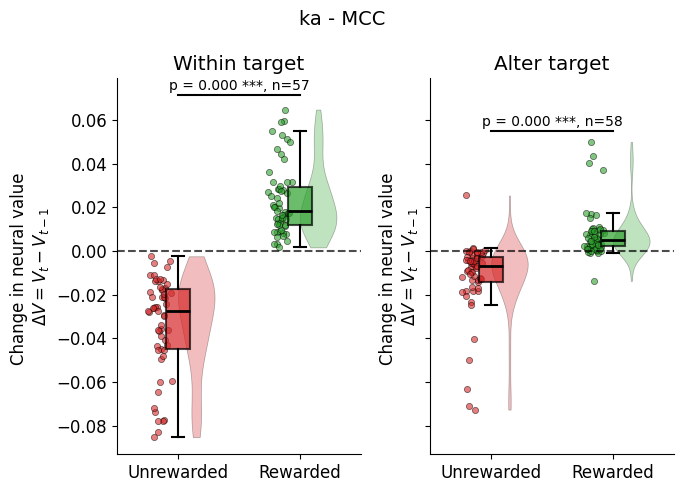

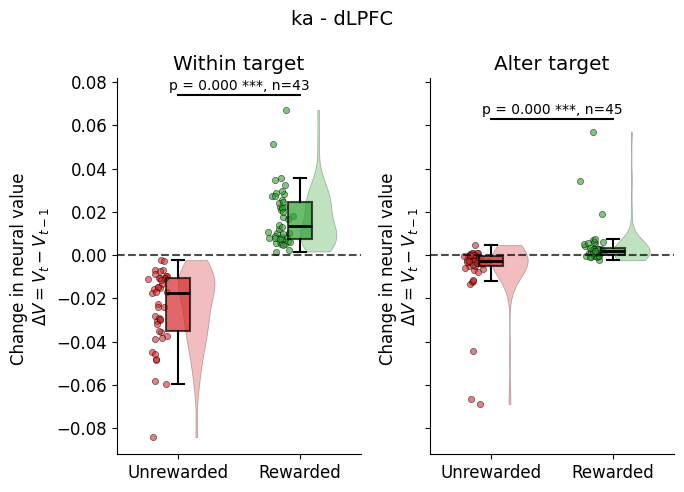

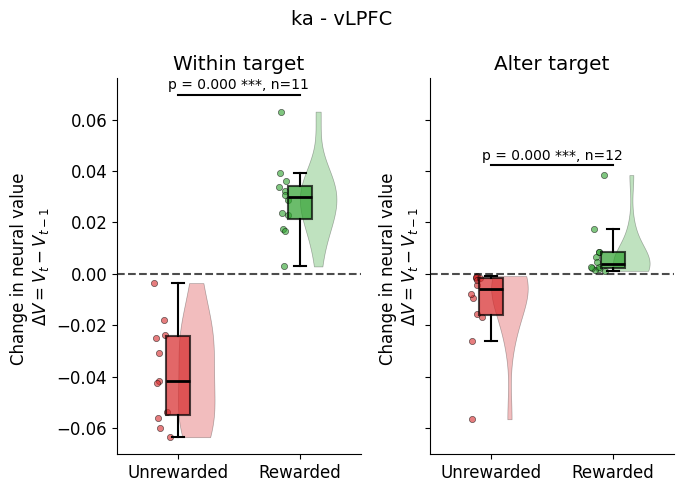

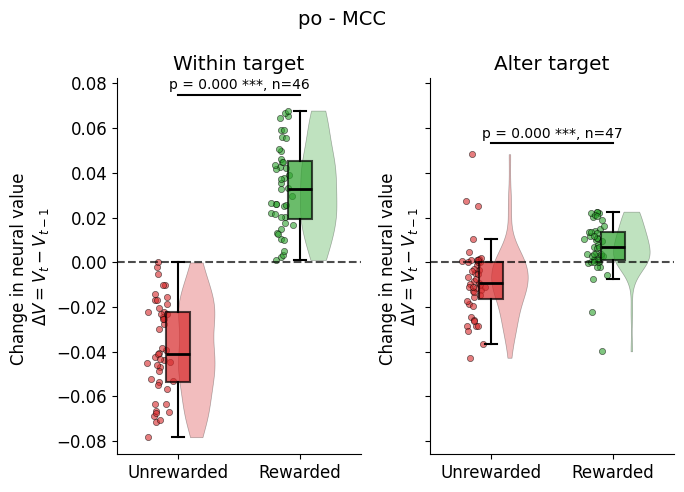

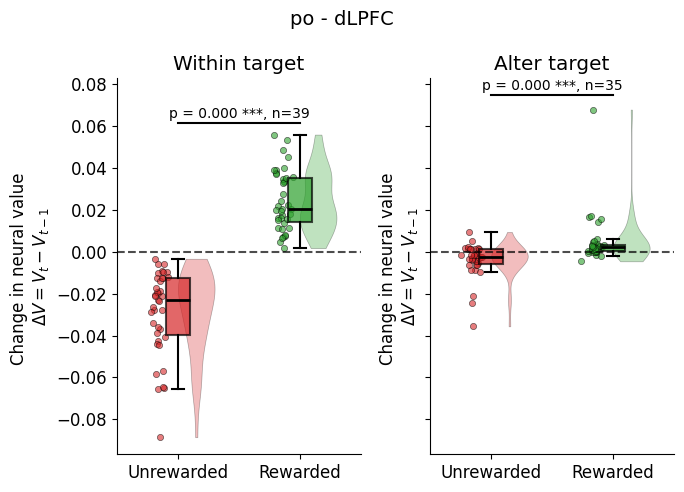

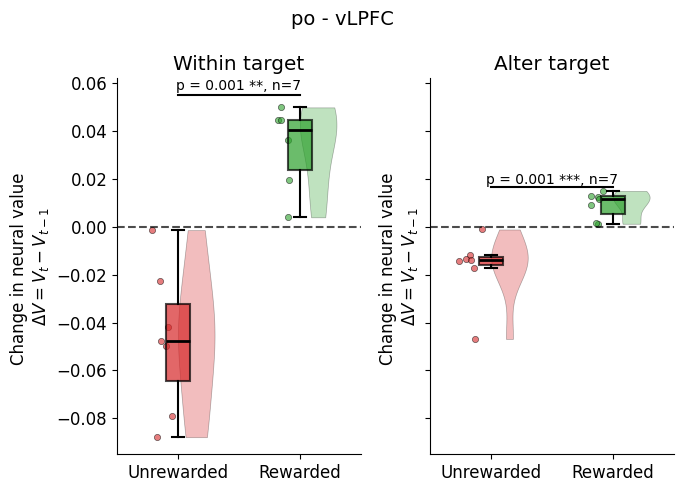

In [9]:
for (monkey, subregion), group in results_df_mean.groupby(['monkey', 'subregion']):
    
    # Create the figure
    fig, axs = plt.subplots(1, 2, figsize=(7, 5), sharey=True)

    # Create the plots
    palette = {'0': 'tab:red', '1': 'tab:green'}

    # Within target plot
    create_r_style_plot(axs[0], 
                    group.loc[group['type'] == 'within'], 
                    'feedback', 'dV_neural', palette, 'Within target')

    # Alter target plot
    create_r_style_plot(axs[1], 
                    group.loc[group['type'] == 'alter'], 
                    'feedback', 'dV_neural', palette, 'Alter target')

    plt.suptitle(f'{monkey} - {subregion}', fontsize=14)
    plt.tight_layout()

    # save svg
    #plt.savefig('figs/dV_neural_behav_rstyle.svg', format='svg', bbox_inches='tight')